In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import h5py
import cv2

In [4]:
def mask_movie(movie, raw_mask, binning, flip=True):
    raw_mask = np.ascontiguousarray(raw_mask.astype(np.float32))

    mask = cv2.resize(
        raw_mask,
        (0, 0),
        fx=1/binning,
        fy=1/binning,
        interpolation=cv2.INTER_LINEAR
    )

    mask = mask[:movie.shape[1], :movie.shape[2]] > 0.5

    if flip:
        mask = np.flipud(mask)

    out = movie.astype(float).copy()
    out[:, ~mask] = np.nan
    return out, mask


def load_movie(path, flip=False, crop_to=1000):
    with h5py.File(path, 'r') as mov_file:
        specs = mov_file["specs"]
        fps = specs['fps'][()].squeeze()
        raw_mask = specs["extra_specs"]["mask"][()].squeeze()
        binning = specs["binning"][()].squeeze()
        spaceorigin = specs["spaceorigin"][()].squeeze()  

        mov = mov_file['mov'][:crop_to]
        movie = np.nan_to_num(mov)
        if flip:
            movie = np.flip(movie, axis=1)

        movie_masked, mask = mask_movie(movie, raw_mask, binning, flip=True)

    return movie, movie_masked, mask



In [47]:
raw_movie_path = 'Y:/Voltage/VisualConsciousness/Preprocessed/Visual/cfm005mjr/20251202/meas01/cfm005mjr_d251202_s01VDT-fps157-cG_bin8_mc.h5'
with h5py.File(raw_movie_path, 'r') as mov_file:
        raw_movie = mov_file['mov'][:5000]


path_noisy = "Y:/Voltage/VisualConsciousness/Analysis/Visual/cfm005mjr/20251202/meas01/cG_unmixedTR_dFF.h5"
dff_movie, movie_masked, brain_mask = load_movie(path_noisy, flip=True, crop_to=5000)

F0_map = np.loadtxt('Y:/Voltage/VisualConsciousness/Preprocessed/Visual/cfm005mjr/20251202/meas01/diagnostic/movieDFF/F0.csv', delimiter=",")
F0_map = np.rot90(F0_map)

In [52]:
# ============================================================
# Gaussian-approximation test for raw fluorescence movie
#
# Assumptions:
# - raw_movie has shape (T, Y, X)
# - F0_map has shape (Y, X)
# - Optional brain_mask has shape (Y, X), boolean
#
# Core idea:
# - Estimate per-pixel noise using temporal differences
# - Test whether variance scales ~ linearly with mean
# - Test whether normalized noise samples look Gaussian
# ============================================================

# ============================================================
# Utility functions
# ============================================================

def robust_mad_std(x, axis=None):
    """
    Robust estimate of standard deviation from MAD.
    """
    med = np.nanmedian(x, axis=axis, keepdims=True)
    mad = np.nanmedian(np.abs(x - med), axis=axis)
    return 1.4826 * mad


def skewness_1d(x):
    """
    Sample skewness (plain moment version).
    """
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if x.size < 3:
        return np.nan
    mu = np.mean(x)
    sd = np.std(x)
    if sd == 0:
        return np.nan
    return np.mean(((x - mu) / sd) ** 3)


def excess_kurtosis_1d(x):
    """
    Sample excess kurtosis (plain moment version).
    Gaussian should be near 0.
    """
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if x.size < 4:
        return np.nan
    mu = np.mean(x)
    sd = np.std(x)
    if sd == 0:
        return np.nan
    return np.mean(((x - mu) / sd) ** 4) - 3


def gaussian_quantiles(n):
    """
    Return theoretical Gaussian quantiles using simulation-free approximation.
    Uses scipy if available; otherwise falls back to normal approximation
    through percentiles of random samples.
    """
    try:
        from scipy.stats import norm
        p = (np.arange(n) + 0.5) / n
        return norm.ppf(p)
    except Exception:
        rng = np.random.default_rng(0)
        z = rng.standard_normal(max(n, 200000))
        p = (np.arange(n) + 0.5) / n
        return np.quantile(z, p)


def qq_plot_against_gaussian(x, ax=None, title=None):
    """
    QQ-style plot of standardized samples against N(0,1).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))

    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if x.size < 20:
        ax.text(0.5, 0.5, "Not enough samples", ha='center', va='center')
        ax.set_axis_off()
        return ax

    x = (x - np.mean(x)) / np.std(x)
    x = np.sort(x)
    q = gaussian_quantiles(len(x))

    ax.plot(q, x, '.', ms=2)
    lo = min(q.min(), x.min())
    hi = max(q.max(), x.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    ax.set_xlabel("Theoretical N(0,1) quantiles")
    ax.set_ylabel("Empirical standardized quantiles")
    if title is not None:
        ax.set_title(title)

    return ax


def bin_by_quantiles(values, n_bins=6, valid_mask=None):
    """
    Bin pixels by quantiles of `values`.
    Returns:
        bin_masks: list of boolean masks
        edges: bin edges
        centers: median value in each bin
    """
    values = np.asarray(values)

    if valid_mask is None:
        valid_mask = np.isfinite(values)
    else:
        valid_mask = valid_mask & np.isfinite(values)

    vals = values[valid_mask]
    edges = np.quantile(vals, np.linspace(0, 1, n_bins + 1))

    # Make edges strictly increasing if repeated quantiles appear
    edges = np.array(edges, dtype=float)
    for i in range(1, len(edges)):
        if edges[i] <= edges[i - 1]:
            edges[i] = edges[i - 1] + 1e-12

    bin_masks = []
    centers = []

    for i in range(n_bins):
        if i < n_bins - 1:
            m = valid_mask & (values >= edges[i]) & (values < edges[i + 1])
        else:
            m = valid_mask & (values >= edges[i]) & (values <= edges[i + 1])

        bin_masks.append(m)
        centers.append(np.nanmedian(values[m]) if np.any(m) else np.nan)

    return bin_masks, edges, np.array(centers)


# ============================================================
# Main analysis functions
# ============================================================

def estimate_noise_from_temporal_differences(raw_movie, use_robust=False):
    """
    Estimate per-pixel noise variance from temporal differences.

    If Y_t = signal_t + noise_t and noise_t are independent with variance sigma^2,
    then Var(Y_{t+1} - Y_t) ~ 2*sigma^2 when signal changes slowly.

    Returns
    -------
    diff_movie : array, shape (T-1, Y, X)
        Temporal differences
    sigma2_map : array, shape (Y, X)
        Estimated per-pixel noise variance
    sigma_map : array, shape (Y, X)
        Estimated per-pixel noise std
    mean_map : array, shape (Y, X)
        Temporal mean of raw movie
    """
    raw_movie = np.asarray(raw_movie, dtype=float)
    diff_movie = np.diff(raw_movie, axis=0)

    if use_robust:
        sigma_map = robust_mad_std(diff_movie, axis=0) / np.sqrt(2)
        sigma2_map = sigma_map ** 2
    else:
        sigma2_map = 0.5 * np.nanvar(diff_movie, axis=0, ddof=1)
        sigma_map = np.sqrt(sigma2_map)

    mean_map = np.nanmean(raw_movie, axis=0)

    return diff_movie, sigma2_map, sigma_map, mean_map


def fit_mean_variance_relationship(mean_map, sigma2_map, valid_mask, fit_percentile_range=(5, 95), f_range=None):
    """
    Fit sigma^2 ~ a * mean + b over valid pixels.

    Optionally trims extreme mean values by percentile to avoid outliers/background.
    """
    m = valid_mask & np.isfinite(mean_map) & np.isfinite(sigma2_map)

    mean_vals = mean_map[m]
    var_vals = sigma2_map[m]

    if f_range:
        lo, hi = f_range[0], f_range[1]
    else:
        lo, hi = np.percentile(mean_vals, fit_percentile_range)
    m2 = m & (mean_map >= lo) & (mean_map <= hi)

    x = mean_map[m2].ravel()
    y = sigma2_map[m2].ravel()

    coeff = np.polyfit(x, y, 1)
    a, b = coeff[0], coeff[1]

    # R^2
    y_pred = a * x + b
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return a, b, r2, m2


def summarize_bins(diff_movie, bin_masks, max_samples_per_bin=200000, rng_seed=0):
    """
    For each brightness bin, collect standardized noise samples and summary stats.

    Uses temporal differences as noise proxy. Since diff variance is ~2*sigma^2,
    we standardize by the empirical std of the samples themselves, so that
    histogram/QQ/skewness tests focus on shape rather than scale.
    """
    rng = np.random.default_rng(rng_seed)
    summaries = []

    for i, bm in enumerate(bin_masks):
        idx = np.flatnonzero(bm.ravel())
        if idx.size == 0:
            summaries.append({
                "bin_index": i,
                "n_pixels": 0,
                "n_samples": 0,
                "samples": np.array([]),
                "skewness": np.nan,
                "excess_kurtosis": np.nan,
                "std": np.nan,
            })
            continue

        # Gather all temporal-difference samples from pixels in this bin
        samples = diff_movie.reshape(diff_movie.shape[0], -1)[:, idx].ravel()
        samples = samples[np.isfinite(samples)]

        if samples.size > max_samples_per_bin:
            keep = rng.choice(samples.size, size=max_samples_per_bin, replace=False)
            samples = samples[keep]

        s = np.std(samples)
        if s > 0:
            z = (samples - np.mean(samples)) / s
        else:
            z = samples * np.nan

        summaries.append({
            "bin_index": i,
            "n_pixels": idx.size,
            "n_samples": samples.size,
            "samples": z,
            "skewness": skewness_1d(z),
            "excess_kurtosis": excess_kurtosis_1d(z),
            "std": s,
        })

    return summaries


def plot_mean_variance(mean_map, sigma2_map, valid_mask, a=None, b=None, n_show=50000, rng_seed=0):
    """
    Scatter plot of noise variance vs mean brightness, with optional fitted line.
    """
    rng = np.random.default_rng(rng_seed)

    m = valid_mask & np.isfinite(mean_map) & np.isfinite(sigma2_map)
    x = mean_map[m].ravel()
    y = sigma2_map[m].ravel()

    if x.size > n_show:
        keep = rng.choice(x.size, size=n_show, replace=False)
        x_plot = x[keep]
        y_plot = y[keep]
    else:
        x_plot = x
        y_plot = y

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(x_plot, y_plot, '.', ms=2, alpha=0.25)

    if a is not None and b is not None:
        xx = np.linspace(np.nanmin(x), np.nanmax(x), 300)
        yy = a * xx + b
        ax.plot(xx, yy, 'r-', lw=2, label=f'fit: var = {a:.4g}*mean + {b:.4g}')
        ax.legend()

    ax.set_xlabel("Raw fluorescence mean")
    ax.set_ylabel("Estimated noise variance from temporal differences")
    ax.set_title("Mean-variance relationship")
    plt.tight_layout()
    plt.show()


def plot_bin_histograms_and_qq(summaries, centers):
    """
    Plot histogram and QQ plot for each brightness bin.
    """
    n_bins = len(summaries)
    fig, axes = plt.subplots(n_bins, 2, figsize=(10, 3.2 * n_bins))

    if n_bins == 1:
        axes = np.array([axes])

    for i, summ in enumerate(summaries):
        axh, axq = axes[i]

        z = summ["samples"]
        center = centers[i]

        if z.size < 20:
            axh.text(0.5, 0.5, "Not enough samples", ha='center', va='center')
            axh.set_axis_off()
            axq.text(0.5, 0.5, "Not enough samples", ha='center', va='center')
            axq.set_axis_off()
            continue

        axh.hist(z, bins=100, density=True, alpha=0.7)
        xx = np.linspace(-5, 5, 400)
        gauss = np.exp(-0.5 * xx**2) / np.sqrt(2 * np.pi)
        axh.plot(xx, gauss, 'k--', lw=1.5)
        axh.set_xlim(-5, 5)
        axh.set_title(
            f"Bin {i+1} | median mean={center:.3g}\n"
            f"skew={summ['skewness']:.3f}, ex.kurt={summ['excess_kurtosis']:.3f}"
        )
        axh.set_xlabel("Standardized temporal-difference samples")
        axh.set_ylabel("Density")

        qq_plot_against_gaussian(z, ax=axq, title=f"QQ plot: bin {i+1}")

    plt.tight_layout()
    plt.show()


def print_bin_summary_table(summaries, centers):
    """
    Print a compact text summary of Gaussianity diagnostics by bin.
    """
    print("\nBrightness-bin Gaussianity summary")
    print("-" * 90)
    print(f"{'Bin':>3} | {'Median mean':>12} | {'N pixels':>9} | {'N samples':>10} | {'Skew':>8} | {'Ex.Kurt':>10}")
    print("-" * 90)
    for i, (summ, c) in enumerate(zip(summaries, centers), start=1):
        print(f"{i:>3} | {c:>12.4g} | {summ['n_pixels']:>9} | {summ['n_samples']:>10} | "
              f"{summ['skewness']:>8.3f} | {summ['excess_kurtosis']:>10.3f}")
    print("-" * 90)


def classify_gaussian_approximation(summaries, centers, verbose=True):
    """
    Heuristic interpretation of whether Gaussian approximation looks reasonable.

    This is not a formal statistical test. It is a practical summary.
    """
    usable = []
    for c, summ in zip(centers, summaries):
        if np.isfinite(summ["skewness"]) and np.isfinite(summ["excess_kurtosis"]):
            usable.append((c, summ["skewness"], summ["excess_kurtosis"], summ["n_pixels"]))

    if len(usable) == 0:
        if verbose:
            print("No usable bins for interpretation.")
        return

    if verbose:
        print("\nHeuristic interpretation")
        print("-" * 90)
        print("Rough guideline:")
        print("  - |skewness| < ~0.2 and |excess kurtosis| < ~0.5 --> pretty Gaussian")
        print("  - moderate deviations in dim bins are expected")
        print("  - what matters most is whether the main cortical-brightness bins look close")
        print("-" * 90)

    for i, (c, sk, ek, npix) in enumerate(usable, start=1):
        if abs(sk) < 0.2 and abs(ek) < 0.5:
            label = "close to Gaussian"
        elif abs(sk) < 0.4 and abs(ek) < 1.0:
            label = "roughly Gaussian / acceptable approximation"
        else:
            label = "noticeably non-Gaussian"

        if verbose:
            print(f"Bin {i}: median mean={c:.4g}, n_pixels={npix}, skew={sk:.3f}, ex.kurt={ek:.3f} --> {label}")


def plot_bin_histograms_only_two_rows(summaries, centers, edges=None, bins=100, xlim=(-5, 5)):
    """
    Plot only the standardized-noise histograms for each brightness bin,
    arranged in two rows.

    Parameters
    ----------
    summaries : list of dict
        Output from summarize_bins(...). Each entry should contain:
            - "samples"
            - "skewness"
            - "excess_kurtosis"
    centers : array-like
        Representative brightness value for each bin (typically median raw fluorescence).
    edges : array-like or None, optional
        Bin edges from bin_by_quantiles(...). If provided, titles will show the
        approximate fluorescence range for each bin instead of just the center.
    bins : int, optional
        Number of histogram bins.
    xlim : tuple, optional
        X-axis limits for standardized samples.
    """
    n_bins = len(summaries)
    n_rows = 2
    n_cols = int(np.ceil(n_bins / n_rows))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.6 * n_rows))
    axes = np.atleast_2d(axes)

    xx = np.linspace(xlim[0], xlim[1], 400)
    gauss = np.exp(-0.5 * xx**2) / np.sqrt(2 * np.pi)

    for i in range(n_rows * n_cols):
        r = i // n_cols
        c = i % n_cols
        ax = axes[r, c]

        if i >= n_bins:
            ax.axis('off')
            continue

        summ = summaries[i]
        z = summ["samples"]

        if z.size < 20:
            ax.text(0.5, 0.5, "Not enough samples", ha='center', va='center')
            ax.set_axis_off()
            continue

        ax.hist(z, bins=bins, density=True, alpha=0.75)
        ax.plot(xx, gauss, 'k--', lw=1.5)
        ax.set_xlim(*xlim)
        ax.set_xlabel("z-scored temporal differences")
        ax.set_ylabel("Density")

        if edges is not None:
            lo = edges[i]
            hi = edges[i + 1]
            title = (
                f"Brightness bin {i+1}\n"
                f"Raw fluorescence: {lo:.0f} to {hi:.0f}\n"
                f"Skew = {summ['skewness']:.3f}, excess kurtosis = {summ['excess_kurtosis']:.3f}"
            )
        else:
            title = (
                f"Brightness bin {i+1}\n"
                f"Typical raw fluorescence: {centers[i]:.0f}\n"
                f"Skew = {summ['skewness']:.3f}, excess kurtosis = {summ['excess_kurtosis']:.3f}"
            )

        ax.set_title(title)

    plt.tight_layout()
    plt.show()

# ============================================================
# Optional: compare variance in dF/F space vs F0
# This is not required for the Gaussian test, but useful context.
# ============================================================

def check_dff_variance_vs_F0(dff_movie, F0_map, valid_mask):
    """
    Useful sanity check:
    in dF/F space, shot-noise-derived variance should tend to decrease with F0.

    This is mostly for intuition and cross-checking, not for the main Gaussian test.
    """
    diff_dff = np.diff(dff_movie.astype(float), axis=0)
    sigma2_dff = 0.5 * np.nanvar(diff_dff, axis=0, ddof=1)

    m = valid_mask & np.isfinite(F0_map) & np.isfinite(sigma2_dff)
    x = F0_map[m].ravel()
    y = sigma2_dff[m].ravel()

    fig, ax = plt.subplots(figsize=(6, 5))
    rng = np.random.default_rng(0)
    if x.size > 50000:
        keep = rng.choice(x.size, size=50000, replace=False)
        x = x[keep]
        y = y[keep]

    ax.plot(x, y, '.', ms=2, alpha=0.25)
    ax.set_xlabel("F0")
    ax.set_ylabel("Estimated dF/F noise variance")
    ax.set_title("Sanity check: dF/F noise variance vs F0")
    plt.tight_layout()
    plt.show()




C:\Users\Katie\AppData\Local\Temp\ipykernel_49552\2251965657.py:174: RuntimeWarning: Degrees of freedom <= 0 for slice.
  sigma2_map = 0.5 * np.nanvar(diff_movie, axis=0, ddof=1)
C:\Users\Katie\AppData\Local\Temp\ipykernel_49552\2251965657.py:177: RuntimeWarning: Mean of empty slice
  mean_map = np.nanmean(raw_movie, axis=0)


Estimated raw-space Poisson-Gaussian relationship:
  noise variance ≈ a * mean + b
  a = 0.253493
  b = -115.331
  R^2 = 0.9848


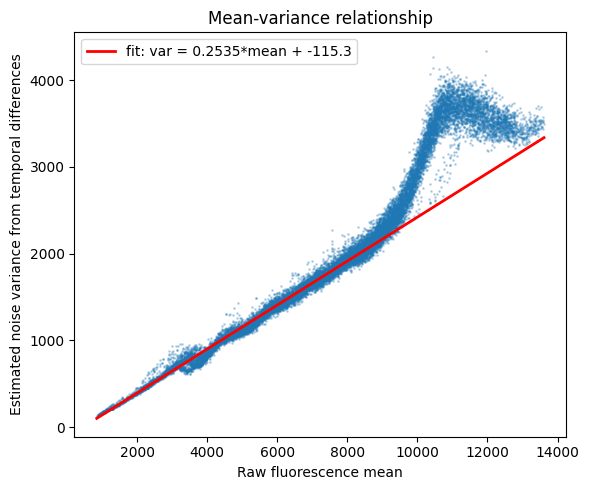

In [54]:
# ============================================================
# Run analysis
# ============================================================

# -------- basic checks --------
assert raw_movie.ndim == 3, "raw_movie must have shape (T, Y, X)"
assert F0_map.ndim == 2, "F0_map must have shape (Y, X)"
assert raw_movie.shape[1:] == F0_map.shape, "raw_movie spatial shape must match F0_map"

if 'brain_mask' not in globals() or brain_mask is None:
    brain_mask = np.ones(F0_map.shape, dtype=bool)

valid_mask = brain_mask & np.isfinite(F0_map)

# Optional: exclude extremely dim / background pixels
# This usually makes the interpretation much cleaner.
f0_vals = F0_map[valid_mask]
f0_lo = np.percentile(f0_vals, 5)
valid_mask = valid_mask & (F0_map >= f0_lo)

# -------- estimate raw-space noise from temporal differences --------
diff_movie, sigma2_map, sigma_map, mean_map = estimate_noise_from_temporal_differences(
    raw_movie,
    use_robust=False,   # change to True if you want a more outlier-robust estimate
)

# -------- fit mean-variance relationship --------
a, b, r2, fit_mask = fit_mean_variance_relationship(
    mean_map,
    sigma2_map,
    valid_mask,
    fit_percentile_range=(5, 95),
    f_range=(1000,8000)
)

print("Estimated raw-space Poisson-Gaussian relationship:")
print(f"  noise variance ≈ a * mean + b")
print(f"  a = {a:.6g}")
print(f"  b = {b:.6g}")
print(f"  R^2 = {r2:.4f}")

plot_mean_variance(mean_map, sigma2_map, valid_mask, a=a, b=b)



Brightness-bin Gaussianity summary
------------------------------------------------------------------------------------------
Bin |  Median mean |  N pixels |  N samples |     Skew |    Ex.Kurt
------------------------------------------------------------------------------------------
  1 |         2911 |      2382 |     200000 |   -0.008 |      0.336
  2 |         4920 |      2381 |     200000 |   -0.004 |      0.057
  3 |         6260 |      2381 |     200000 |    0.002 |      0.009
  4 |         7382 |      2381 |     200000 |    0.008 |      0.028
  5 |         8482 |      2382 |     200000 |   -0.009 |      0.010
  6 |         9370 |      2381 |     200000 |   -0.015 |      0.080
  7 |    1.042e+04 |      2381 |     200000 |   -0.007 |      0.077
  8 |     1.18e+04 |      2382 |     200000 |   -0.007 |      0.014
------------------------------------------------------------------------------------------

Heuristic interpretation
-----------------------------------------------------

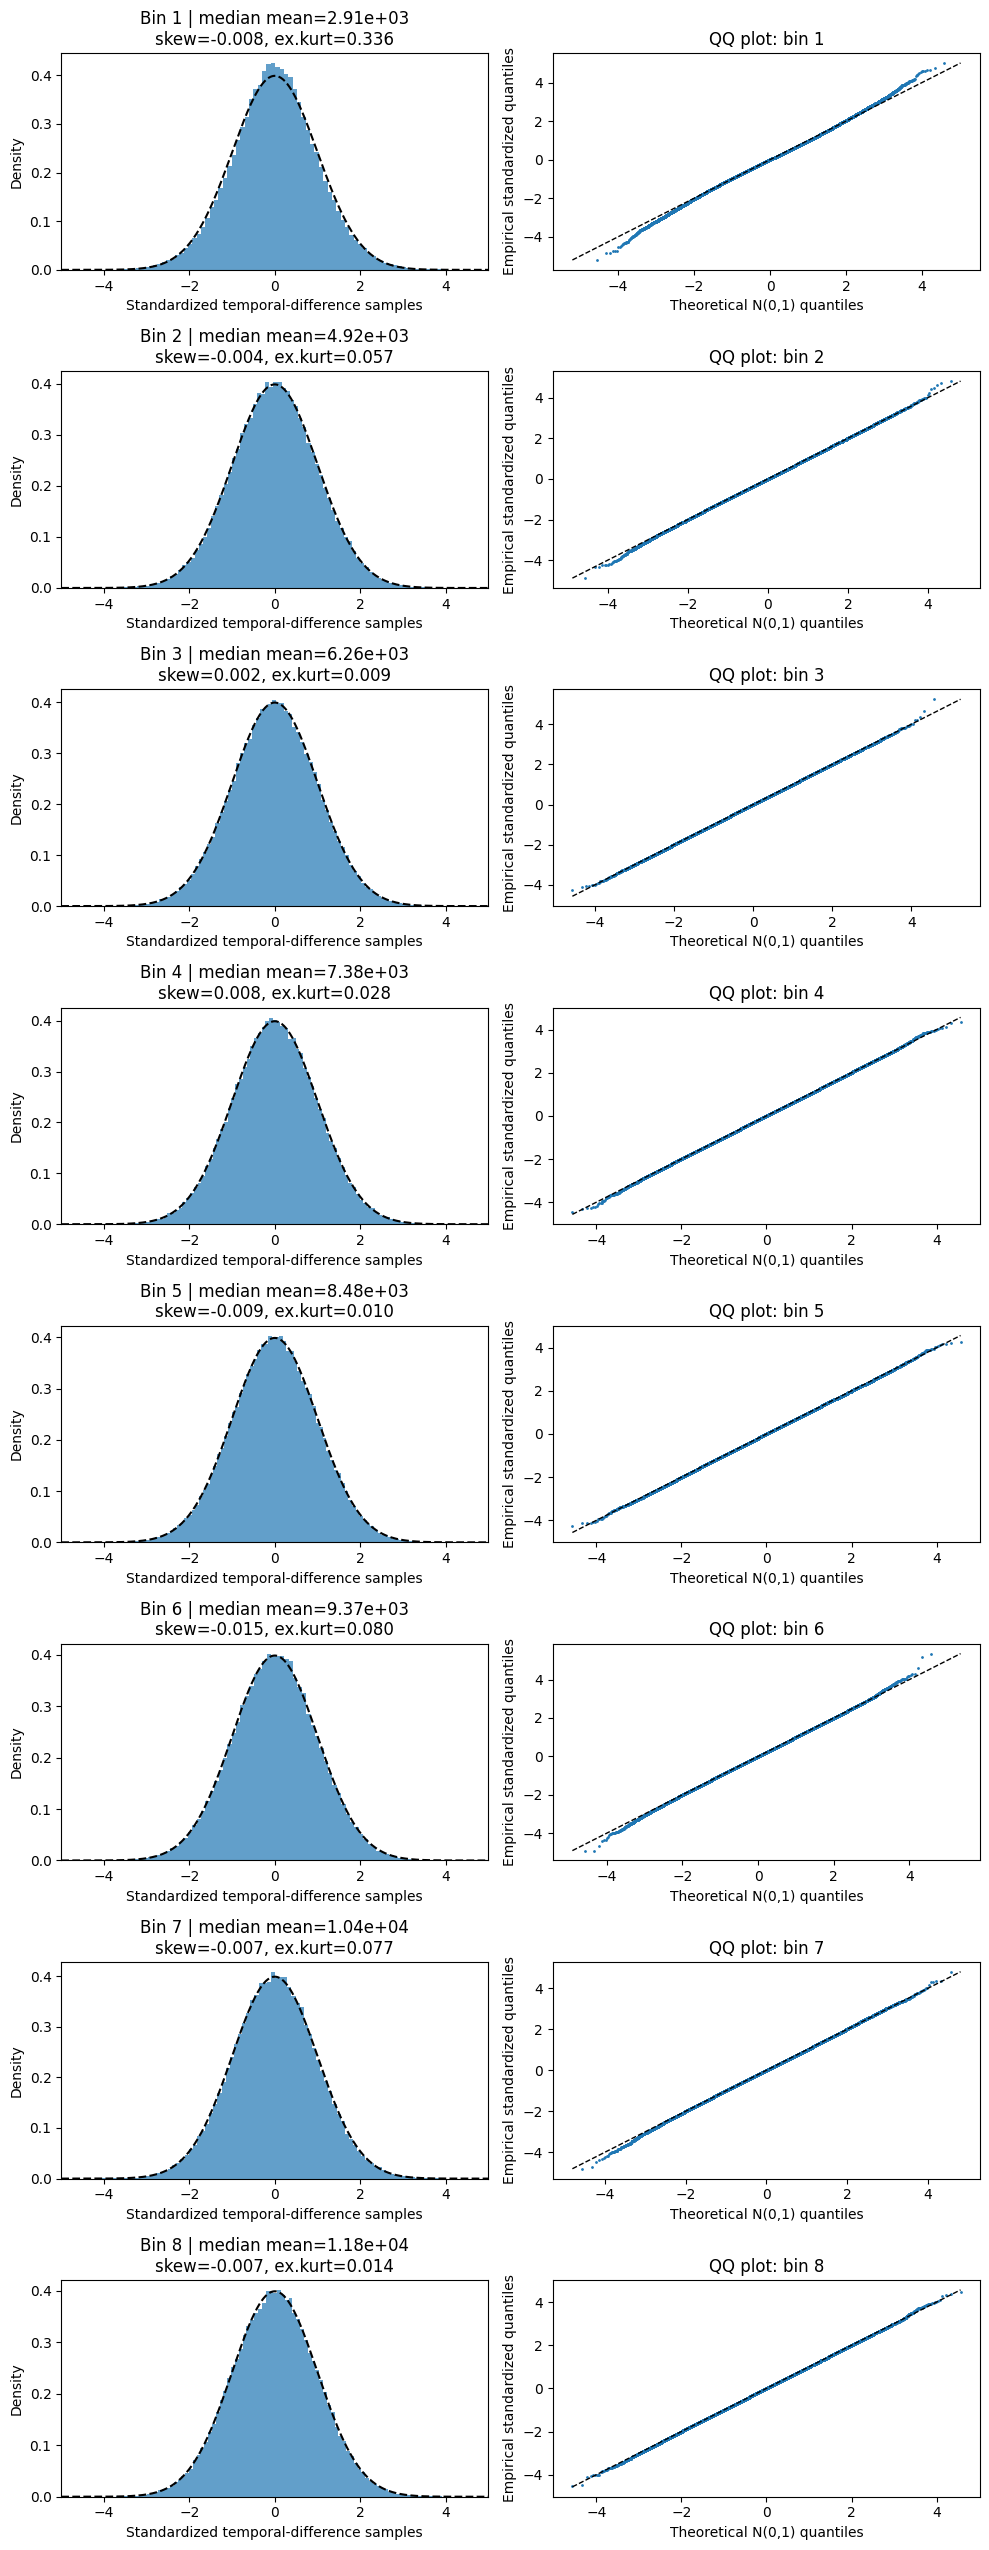

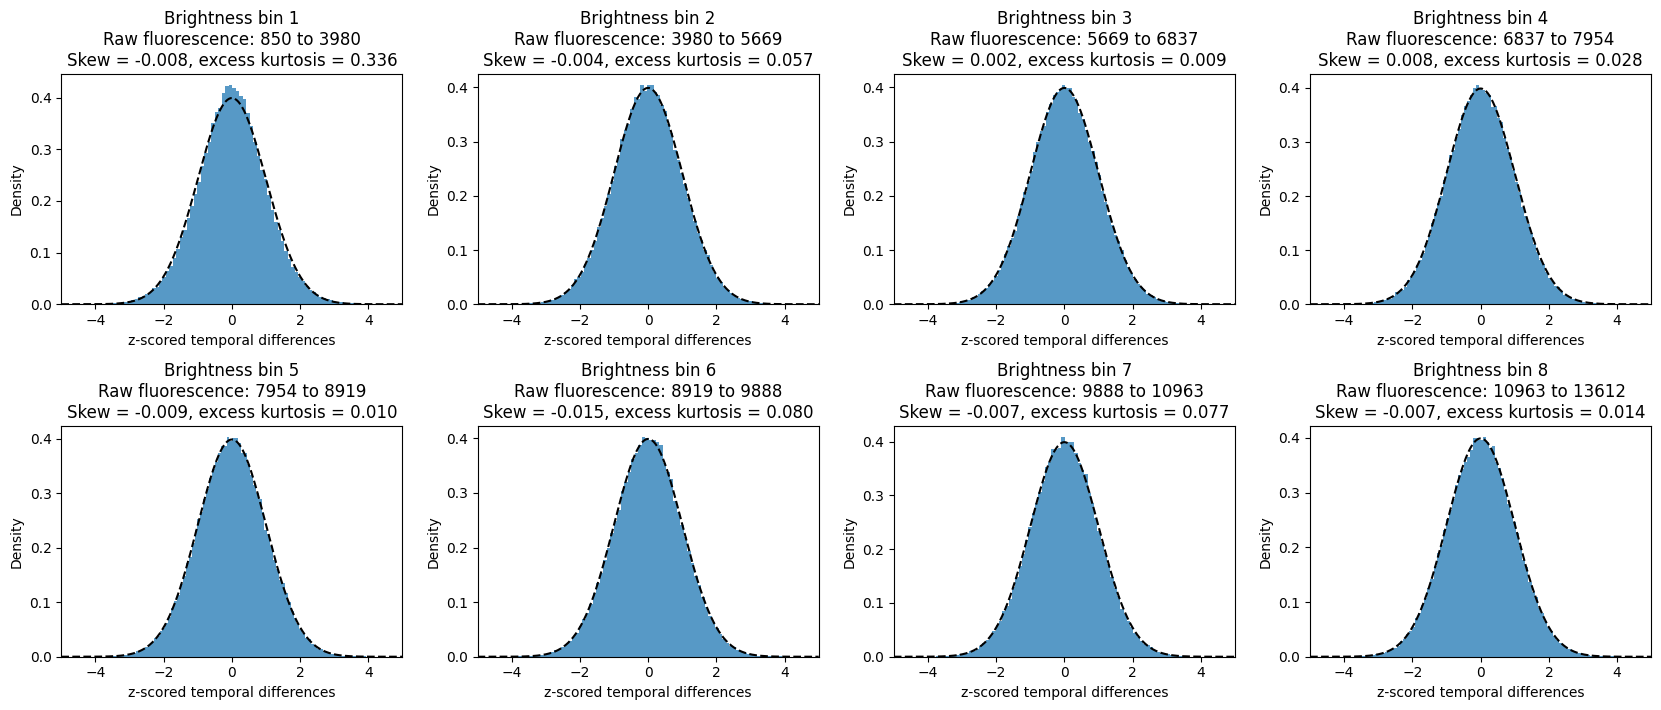

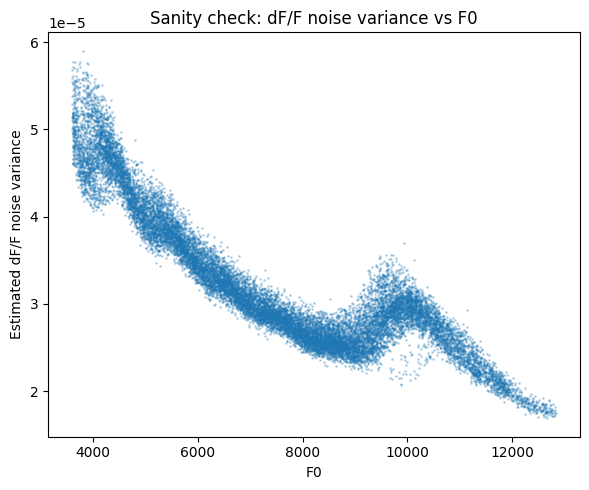

In [50]:

# -------- brightness-bin Gaussianity test --------
# I recommend binning by raw mean brightness.
bin_masks, edges, centers = bin_by_quantiles(mean_map, n_bins=8, valid_mask=valid_mask)

summaries = summarize_bins(
    diff_movie,
    bin_masks,
    max_samples_per_bin=200000,
    rng_seed=0,
)

print_bin_summary_table(summaries, centers)
classify_gaussian_approximation(summaries, centers, verbose=True)
plot_bin_histograms_and_qq(summaries, centers)

plot_bin_histograms_only_two_rows(summaries, centers, edges=edges)

# ============================================================
# Optional extra check: dF/F-space variance vs F0
# Uncomment if you want it and have dff_movie loaded
# ============================================================

check_dff_variance_vs_F0(dff_movie, F0_map, valid_mask)

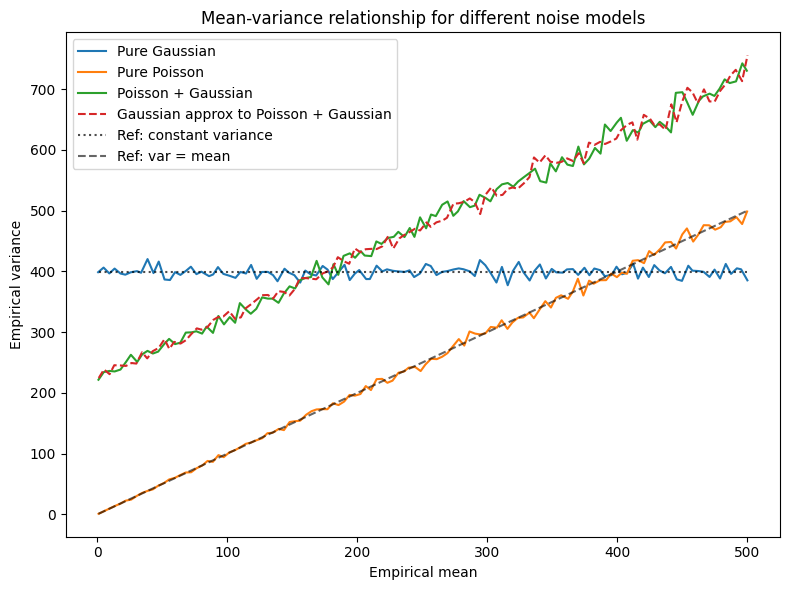

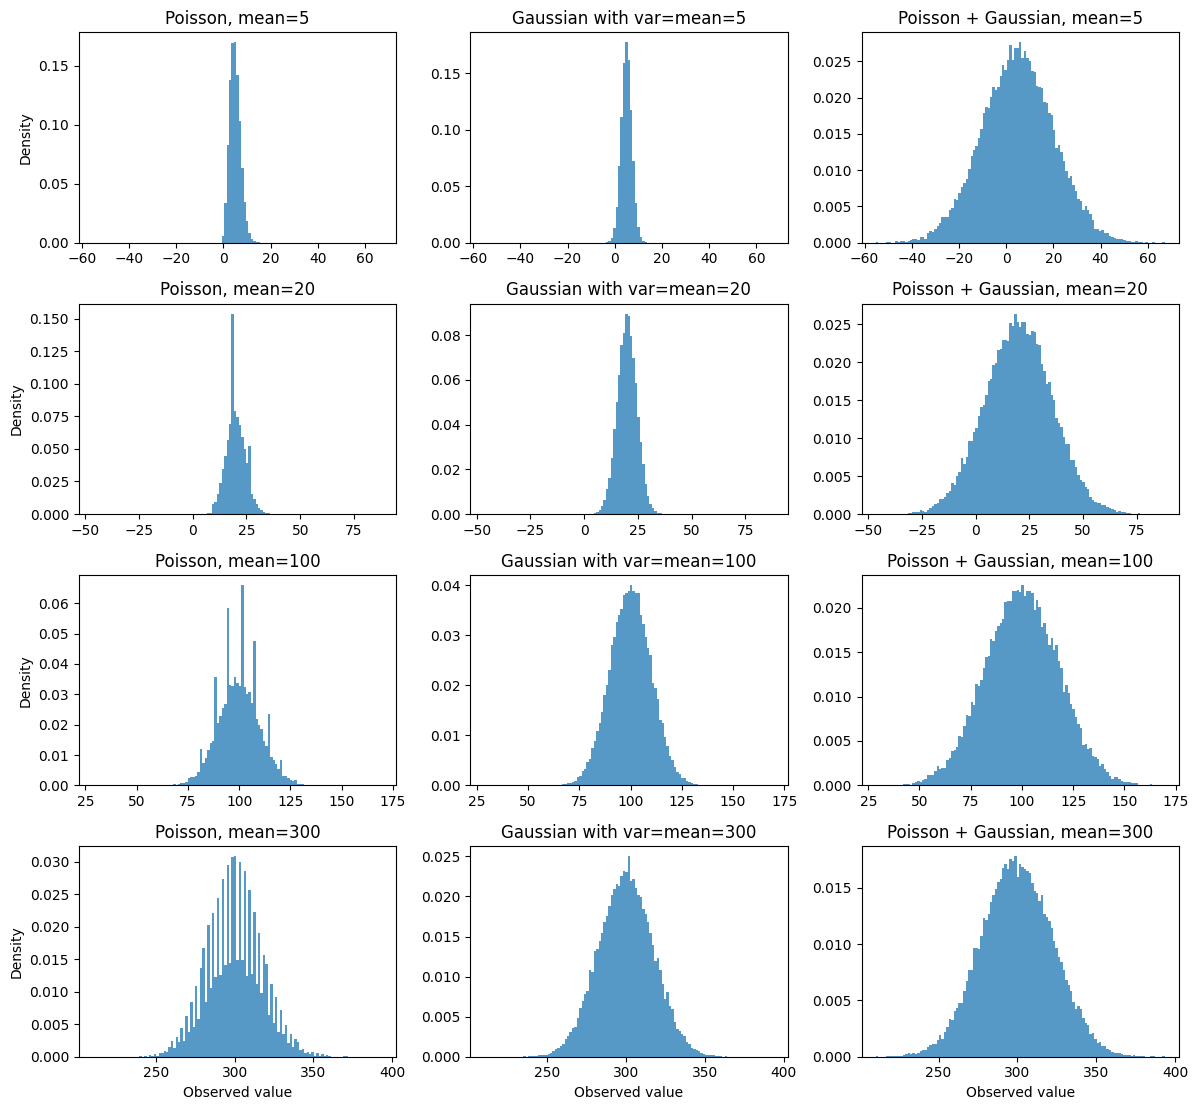

In [46]:
# ============================================================
# Demo: mean-variance relationships for Gaussian, Poisson,
# and Poisson-Gaussian noise
#
# This is just for intuition / exploration.
# Not meant to mimic your voltage imaging pipeline exactly.
# ============================================================

# Assumes numpy and matplotlib are already imported in your notebook.


def simulate_mean_variance_curves(
    mean_levels=None,
    n_repeats=2000,
    gaussian_sigma=20.0,
    pg_read_sigma=15.0,
    random_seed=0,
):
    """
    Simulate noisy observations at a range of mean signal levels and compute
    empirical mean and variance for different noise models.

    Parameters
    ----------
    mean_levels : array-like or None
        Underlying signal levels to simulate.
    n_repeats : int
        Number of repeated samples at each mean level.
    gaussian_sigma : float
        Std dev for constant-variance Gaussian noise.
    pg_read_sigma : float
        Read-noise std dev for Poisson-Gaussian model.
    random_seed : int
        RNG seed.

    Returns
    -------
    results : dict
        Dictionary of arrays with empirical means and variances.
    """
    rng = np.random.default_rng(random_seed)

    if mean_levels is None:
        mean_levels = np.linspace(1, 500, 120)

    mean_levels = np.asarray(mean_levels, dtype=float)

    out = {
        "true_mean": mean_levels,
        "gaussian_mean": [],
        "gaussian_var": [],
        "poisson_mean": [],
        "poisson_var": [],
        "poisson_gaussian_mean": [],
        "poisson_gaussian_var": [],
        "gaussian_approx_pg_mean": [],
        "gaussian_approx_pg_var": [],
    }

    for mu in mean_levels:
        # ----------------------------------------------------
        # 1. Pure Gaussian noise: Y = mu + N(0, sigma^2)
        # Variance should be constant with mean
        # ----------------------------------------------------
        y_g = mu + rng.normal(0, gaussian_sigma, size=n_repeats)

        # ----------------------------------------------------
        # 2. Pure Poisson noise: Y ~ Poisson(mu)
        # Mean ~ mu, variance ~ mu
        # ----------------------------------------------------
        y_p = rng.poisson(mu, size=n_repeats)

        # ----------------------------------------------------
        # 3. Poisson-Gaussian noise:
        # Y = Poisson(mu) + N(0, read_sigma^2)
        # Variance ~ mu + read_sigma^2
        # ----------------------------------------------------
        y_pg = rng.poisson(mu, size=n_repeats) + rng.normal(0, pg_read_sigma, size=n_repeats)

        # ----------------------------------------------------
        # 4. Gaussian approximation to Poisson-Gaussian:
        # Y ~ N(mu, mu + read_sigma^2)
        # This should overlap with Poisson-Gaussian for high mu
        # ----------------------------------------------------
        y_pg_gauss = mu + rng.normal(0, np.sqrt(mu + pg_read_sigma**2), size=n_repeats)

        # Store empirical stats
        out["gaussian_mean"].append(np.mean(y_g))
        out["gaussian_var"].append(np.var(y_g, ddof=1))

        out["poisson_mean"].append(np.mean(y_p))
        out["poisson_var"].append(np.var(y_p, ddof=1))

        out["poisson_gaussian_mean"].append(np.mean(y_pg))
        out["poisson_gaussian_var"].append(np.var(y_pg, ddof=1))

        out["gaussian_approx_pg_mean"].append(np.mean(y_pg_gauss))
        out["gaussian_approx_pg_var"].append(np.var(y_pg_gauss, ddof=1))

    # Convert lists to arrays
    for k in out:
        out[k] = np.asarray(out[k])

    return out


def plot_mean_variance_demo(results):
    """
    Plot empirical mean-variance curves for the simulated noise models.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    # Empirical curves
    ax.plot(results["gaussian_mean"], results["gaussian_var"], label="Pure Gaussian")
    ax.plot(results["poisson_mean"], results["poisson_var"], label="Pure Poisson")
    ax.plot(results["poisson_gaussian_mean"], results["poisson_gaussian_var"], label="Poisson + Gaussian")
    ax.plot(
        results["gaussian_approx_pg_mean"],
        results["gaussian_approx_pg_var"],
        "--",
        label="Gaussian approx to Poisson + Gaussian",
    )

    # Reference theoretical lines
    mu = results["true_mean"]

    # For pure Gaussian: constant variance
    gaussian_sigma_est = np.mean(results["gaussian_var"])
    ax.plot(mu, np.full_like(mu, gaussian_sigma_est), "k:", alpha=0.7, label="Ref: constant variance")

    # For pure Poisson: var = mean
    ax.plot(mu, mu, "k--", alpha=0.6, label="Ref: var = mean")

    ax.set_xlabel("Empirical mean")
    ax.set_ylabel("Empirical variance")
    ax.set_title("Mean-variance relationship for different noise models")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_sample_histograms_at_selected_means(
    selected_means=(5, 20, 100, 300),
    n_repeats=50000,
    gaussian_sigma=20.0,
    pg_read_sigma=15.0,
    random_seed=0,
):
    """
    Plot sample histograms at a few mean levels so you can see how
    Poisson shape changes with lambda.
    """
    rng = np.random.default_rng(random_seed)

    n_rows = len(selected_means)
    fig, axes = plt.subplots(n_rows, 3, figsize=(12, 2.8 * n_rows))

    if n_rows == 1:
        axes = np.array([axes])

    for i, mu in enumerate(selected_means):
        # Generate samples
        y_p = rng.poisson(mu, size=n_repeats)
        y_g = mu + rng.normal(0, np.sqrt(mu), size=n_repeats)  # Gaussian matched to Poisson mean/var
        y_pg = rng.poisson(mu, size=n_repeats) + rng.normal(0, pg_read_sigma, size=n_repeats)

        # Choose a common x-range
        x_min = min(np.min(y_p), np.min(y_g), np.min(y_pg))
        x_max = max(np.max(y_p), np.max(y_g), np.max(y_pg))
        bins = np.linspace(x_min, x_max, 120)

        # Poisson
        ax = axes[i, 0]
        ax.hist(y_p, bins=bins, density=True, alpha=0.75)
        ax.set_title(f"Poisson, mean={mu}")
        ax.set_ylabel("Density")

        # Gaussian matched to Poisson
        ax = axes[i, 1]
        ax.hist(y_g, bins=bins, density=True, alpha=0.75)
        ax.set_title(f"Gaussian with var=mean={mu}")

        # Poisson + Gaussian
        ax = axes[i, 2]
        ax.hist(y_pg, bins=bins, density=True, alpha=0.75)
        ax.set_title(f"Poisson + Gaussian, mean={mu}")

    for ax in axes[-1, :]:
        ax.set_xlabel("Observed value")

    plt.tight_layout()
    plt.show()


# ============================================================
# Run the demo
# ============================================================

results = simulate_mean_variance_curves(
    mean_levels=np.linspace(1, 500, 120),
    n_repeats=4000,
    gaussian_sigma=20.0,
    pg_read_sigma=15.0,
    random_seed=0,
)

plot_mean_variance_demo(results)

plot_sample_histograms_at_selected_means(
    selected_means=(5, 20, 100, 300),
    n_repeats=30000,
    gaussian_sigma=20.0,
    pg_read_sigma=15.0,
    random_seed=1,
)